# TSP Extensions

Continuation of `01_tsp_walkthrough.ipynb`. Each section is one of the exercises
listed at the end of that notebook, worked out end-to-end.

1. **Asymmetric distances** — add a wind vector and watch the optimal tour twist.
2. **Pin a node** — force a specific node to be visited first.
3. **Forbid an edge** — prevent the solver from using a particular arc.
4. **Time vs quality** — measure how long the local search needs to be useful.
5. **Brute-force baseline** — verify OR-Tools really finds the optimum on small instances.

In [1]:
%load_ext autoreload
%autoreload 2

import itertools
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

from vrp_lib import euclidean_distance_matrix, solve_routing

random.seed(42)
np.random.seed(42)

# Reproduce the same 12-node instance as the walkthrough.
N = 12
points = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(N)]
SCALE = 100
sym_matrix = euclidean_distance_matrix(points, scale=SCALE)

baseline = solve_routing(sym_matrix, time_limit_seconds=2)
print("Symmetric baseline objective:", baseline.total_distance)
print("Route:", " -> ".join(map(str, baseline.routes[0])))

Symmetric baseline objective: 27225
Route: 0 -> 9 -> 3 -> 10 -> 2 -> 7 -> 8 -> 5 -> 6 -> 1 -> 11 -> 4 -> 0


## 1. Asymmetric distances

Real-world routing is rarely symmetric: one-way streets, traffic, wind, currents, hills. We'll simulate a steady **eastward wind** — travelling east is cheaper than travelling west by the same Euclidean distance.

We adjust each arc cost by the cosine of the angle between the travel direction and the wind direction:

$$ d'_{ij} = d_{ij} \cdot (1 - \alpha \cdot \cos\theta_{ij}) $$

Going *with* the wind ($\cos\theta = +1$) shrinks the cost; going *against* it grows the cost.

OR-Tools handles this with **zero code changes** — the routing model never assumed `d[i][j] == d[j][i]`. The only thing that matters is what your callback returns.

In [2]:
def asymmetric_matrix(pts, wind=(1.0, 0.0), alpha=0.4, scale=SCALE):
    """Euclidean distance scaled by alignment with a wind vector."""
    n = len(pts)
    wmag = math.hypot(*wind)
    m = [[0] * n for _ in range(n)]
    for i, (xi, yi) in enumerate(pts):
        for j, (xj, yj) in enumerate(pts):
            if i == j:
                continue
            dx, dy = xj - xi, yj - yi
            d = math.hypot(dx, dy)
            cos_theta = (dx * wind[0] + dy * wind[1]) / (d * wmag)
            m[i][j] = int(round(d * (1 - alpha * cos_theta) * scale))
    return m


asym_matrix = asymmetric_matrix(points)

print(f"d[0][1] (east-ish) = {asym_matrix[0][1]}")
print(f"d[1][0] (west-ish) = {asym_matrix[1][0]}")
print(f"symmetric d       = {sym_matrix[0][1]}")

asym_result = solve_routing(asym_matrix, time_limit_seconds=2)
print()
print("Asymmetric objective:", asym_result.total_distance)
print("Asymmetric route:   ", " -> ".join(map(str, asym_result.routes[0])))
print("Symmetric  route:   ", " -> ".join(map(str, baseline.routes[0])))

d[0][1] (east-ish) = 5606
d[1][0] (west-ish) = 2691
symmetric d       = 4148



Asymmetric objective: 27224
Asymmetric route:    0 -> 4 -> 11 -> 1 -> 6 -> 5 -> 8 -> 7 -> 2 -> 10 -> 3 -> 9 -> 0
Symmetric  route:    0 -> 9 -> 3 -> 10 -> 2 -> 7 -> 8 -> 5 -> 6 -> 1 -> 11 -> 4 -> 0


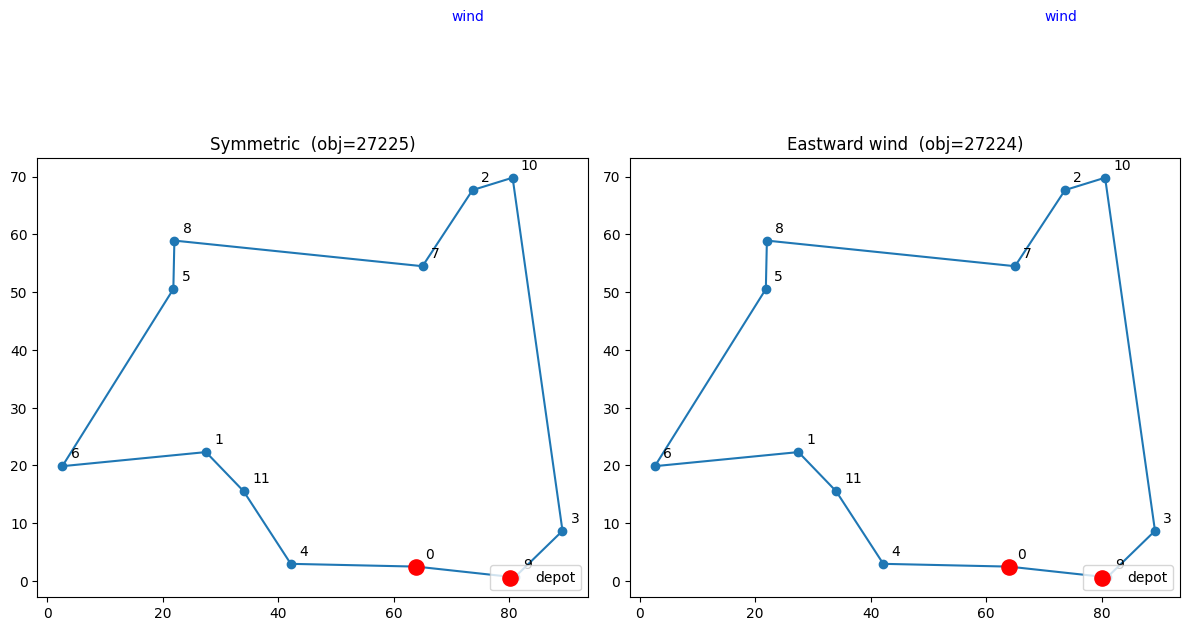

In [3]:
def plot_two_routes(points, routes, titles, wind=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, route, title in zip(axes, routes, titles):
        xs = [points[i][0] for i in route]
        ys = [points[i][1] for i in route]
        ax.plot(xs, ys, "-o")
        ax.scatter(*points[0], c="red", s=120, zorder=5, label="depot")
        for i, (x, y) in enumerate(points):
            ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 6))
        if wind is not None:
            ax.annotate("", xy=(90, 95), xytext=(70, 95),
                        arrowprops=dict(arrowstyle="->", color="blue", lw=2))
            ax.text(70, 97, "wind", color="blue")
        ax.set_aspect("equal"); ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()


plot_two_routes(
    points,
    [baseline.routes[0], asym_result.routes[0]],
    [f"Symmetric  (obj={baseline.total_distance})",
     f"Eastward wind  (obj={asym_result.total_distance})"],
    wind=True,
)

Notice the asymmetric tour tends to traverse long east-bound legs (going with the wind) and short west-bound ones — the solver naturally reorders to exploit the cheap direction.

**Takeaway:** asymmetry is free with the callback API. The cost of an arc is just whatever your function returns.

## 2. Pin a node

Sometimes you need to *force* a particular ordering — e.g. "always start by visiting the high-priority customer at node 5". OR-Tools exposes the solver's decision variables directly:

- `routing.NextVar(index)` is the decision variable for "what comes after `index`".
- `.SetValues([allowed_indices])` restricts that variable to a subset.
- `.RemoveValue(index)` removes one possibility (used in §3).

Constraints must be applied **after** the model is built but **before** solving.

In [4]:
def solve_with_first_pinned(matrix, pinned_node, depot=0, time_limit=2):
    n = len(matrix)
    manager = pywrapcp.RoutingIndexManager(n, 1, depot)
    routing = pywrapcp.RoutingModel(manager)

    def cb(fi, ti):
        return matrix[manager.IndexToNode(fi)][manager.IndexToNode(ti)]

    tcb = routing.RegisterTransitCallback(cb)
    routing.SetArcCostEvaluatorOfAllVehicles(tcb)

    # Force vehicle 0's first move from the depot to be `pinned_node`.
    start = routing.Start(0)
    routing.NextVar(start).SetValues([manager.NodeToIndex(pinned_node)])

    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit)

    sol = routing.SolveWithParameters(params)
    if sol is None:
        raise RuntimeError("Solver returned no solution")

    route, idx = [], routing.Start(0)
    while not routing.IsEnd(idx):
        route.append(manager.IndexToNode(idx))
        idx = sol.Value(routing.NextVar(idx))
    route.append(manager.IndexToNode(idx))
    return route, sol.ObjectiveValue()


pinned_route, pinned_obj = solve_with_first_pinned(sym_matrix, pinned_node=5)
print("Pinned route:    ", " -> ".join(map(str, pinned_route)))
print(f"Pinned objective:  {pinned_obj}  (baseline {baseline.total_distance})")
print(f"Cost of the pin:   +{pinned_obj - baseline.total_distance}")
assert pinned_route[1] == 5, "Node 5 must come immediately after depot"

Pinned route:     0 -> 5 -> 8 -> 6 -> 1 -> 11 -> 4 -> 7 -> 2 -> 10 -> 3 -> 9 -> 0
Pinned objective:  33493  (baseline 27225)
Cost of the pin:   +6268


The route now starts `0 -> 5 -> ...` and the objective is **higher** than the unpinned baseline — the pin makes the problem more constrained, so the best feasible answer can only get worse (or stay the same). The gap quantifies the cost of the business rule.

## 3. Forbid an edge

Two ways to express "don't use arc $(i, j)$":

1. **Big-M in the cost** — set `d[i][j]` to a huge number. The solver *can* use it but never will if any feasible alternative exists. Simple, but the edge isn't truly forbidden.
2. **Domain restriction** — call `routing.NextVar(i).RemoveValue(j)`. The edge becomes structurally impossible.

The baseline tour uses edge `8 -> 5` (visually one of the shortest hops on the plot), so banning that pair forces the solver to find a different route — making the ban *visible* in the objective.

In [5]:
BIG = 10**9
BANNED = [(8, 5), (5, 8)]

def with_big_m(matrix, banned):
    out = [row[:] for row in matrix]
    for a, b in banned:
        out[a][b] = BIG
    return out

banned_matrix = with_big_m(sym_matrix, BANNED)
bigm_result = solve_routing(banned_matrix, time_limit_seconds=2)

route = bigm_result.routes[0]
for a, b in zip(route, route[1:]):
    assert (a, b) not in set(BANNED), f"Edge {a}->{b} was used"

print("Big-M route:    ", " -> ".join(map(str, route)))
print("Big-M objective:", bigm_result.total_distance, " (baseline", baseline.total_distance, ")")

Big-M route:     0 -> 9 -> 3 -> 10 -> 2 -> 7 -> 8 -> 6 -> 5 -> 1 -> 11 -> 4 -> 0
Big-M objective: 31125  (baseline 27225 )


In [6]:
def solve_with_banned_edges(matrix, banned, depot=0, time_limit=2):
    n = len(matrix)
    manager = pywrapcp.RoutingIndexManager(n, 1, depot)
    routing = pywrapcp.RoutingModel(manager)

    def cb(fi, ti):
        return matrix[manager.IndexToNode(fi)][manager.IndexToNode(ti)]

    tcb = routing.RegisterTransitCallback(cb)
    routing.SetArcCostEvaluatorOfAllVehicles(tcb)

    for a, b in banned:
        routing.NextVar(manager.NodeToIndex(a)).RemoveValue(manager.NodeToIndex(b))

    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit)

    sol = routing.SolveWithParameters(params)
    route, idx = [], routing.Start(0)
    while not routing.IsEnd(idx):
        route.append(manager.IndexToNode(idx))
        idx = sol.Value(routing.NextVar(idx))
    route.append(manager.IndexToNode(idx))
    return route, sol.ObjectiveValue()


domain_route, domain_obj = solve_with_banned_edges(sym_matrix, BANNED)
print("Domain route:    ", " -> ".join(map(str, domain_route)))
print("Domain objective:", domain_obj, " (baseline", baseline.total_distance, ")")
assert all((a, b) not in set(BANNED) for a, b in zip(domain_route, domain_route[1:]))

Domain route:     0 -> 9 -> 3 -> 10 -> 2 -> 7 -> 8 -> 6 -> 5 -> 1 -> 11 -> 4 -> 0
Domain objective: 31125  (baseline 27225 )


Both approaches produce a feasible route avoiding `8 <-> 5`, and the objective increased above the baseline — proof the ban actually changed the solver's choices.

**Prefer `RemoveValue`** for hard constraints — it's structurally cleaner and avoids the (very small) chance of Big-M overflow combining badly with other costs.

Big-M is more flexible when the rule is *soft* (\"strongly discourage but allow\"): use a moderate penalty instead of `10**9`.

## 4. Time vs quality on a 200-node TSP

Local search needs time. With a 1s budget the solver mostly returns the initial heuristic solution; with 30s it has time to escape local optima. Let's see the curve.

In [7]:
random.seed(7)
big_points = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(200)]
big_matrix = euclidean_distance_matrix(big_points, scale=SCALE)

rows = []
for t in [1, 3, 10, 30]:
    t0 = time.perf_counter()
    r = solve_routing(big_matrix, time_limit_seconds=t)
    rows.append({
        "time_limit_s": t,
        "wall_s": round(time.perf_counter() - t0, 2),
        "objective": r.total_distance,
    })

df = pd.DataFrame(rows)
best = df["objective"].min()
df["gap_pct"] = ((df["objective"] - best) / best * 100).round(2)
df

,time_limit_s,wall_s,objective,gap_pct
0,1,1.0,114962,0.34
1,3,3.0,114744,0.14
2,10,10.0,114744,0.14
3,30,30.0,114578,0.00


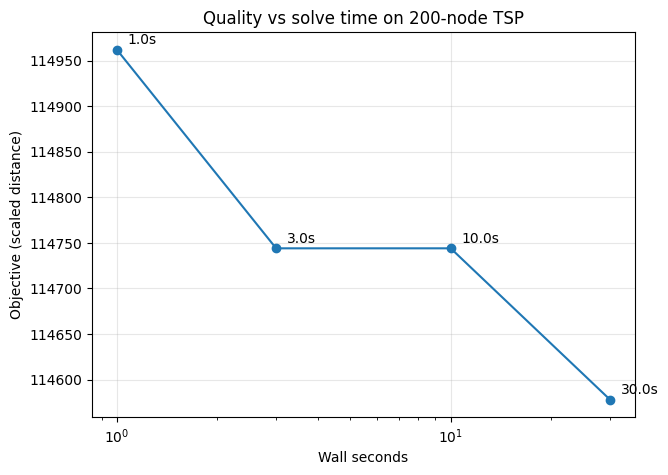

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df["wall_s"], df["objective"], "o-")
for _, row in df.iterrows():
    ax.annotate(f"{row['time_limit_s']}s", (row["wall_s"], row["objective"]),
                textcoords="offset points", xytext=(8, 4))
ax.set_xlabel("Wall seconds")
ax.set_ylabel("Objective (scaled distance)")
ax.set_title("Quality vs solve time on 200-node TSP")
ax.set_xscale("log")
ax.grid(alpha=0.3)
plt.show()

Expect a sharp drop in objective from 1s to ~3s, then **diminishing returns** as GLS approaches a strong local optimum. The exact shape depends on the instance — try changing `random.seed(7)` to see how stable that elbow is.

## 5. Brute-force baseline

How do we know OR-Tools is actually finding good answers? On a small enough instance we can enumerate every permutation and compare. TSP has $(n-1)!$ tours starting from a fixed depot — manageable up to about $n = 10$.

Symmetric TSP also has the property that every tour has a mirror image of equal cost, so we can halve the work by fixing the second node to be smaller than the last — but the naive version is fine here.

In [9]:
def brute_force_tsp(matrix, depot=0):
    n = len(matrix)
    others = [i for i in range(n) if i != depot]
    best_cost, best_route = float("inf"), None
    for perm in itertools.permutations(others):
        route = (depot,) + perm + (depot,)
        cost = sum(matrix[a][b] for a, b in zip(route, route[1:]))
        if cost < best_cost:
            best_cost, best_route = cost, list(route)
    return best_cost, best_route


rows = []
for size in [6, 8, 10]:
    pts = points[:size]
    mat = euclidean_distance_matrix(pts, scale=SCALE)

    t0 = time.perf_counter()
    bf_cost, bf_route = brute_force_tsp(mat)
    bf_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    or_result = solve_routing(mat, time_limit_seconds=2)
    or_time = time.perf_counter() - t0

    rows.append({
        "n": size,
        "perms": math.factorial(size - 1),
        "brute_cost": bf_cost,
        "brute_s": round(bf_time, 3),
        "or_cost": or_result.total_distance,
        "or_s": round(or_time, 3),
        "match": bf_cost == or_result.total_distance,
    })

pd.DataFrame(rows)

,n,perms,brute_cost,brute_s,or_cost,or_s,match
0,6,120,21638,0.000,21638,2.002,True
1,8,5040,25329,0.006,25329,2.002,True
2,10,362880,26414,0.468,26414,2.002,True


All three sizes should show `match = True`: OR-Tools matches the brute-force optimum exactly. The `perms` column makes the wall of factorials concrete — `n=10` is 362,880 tours, `n=12` would already be 39 million. This is why we need heuristics.

## Where to go next

TSP fundamentals are covered. Natural next explorations:

- **CVRP** — capacitated VRP: multiple vehicles, each with a load limit. Adds the `AddDimensionWithVehicleCapacity` API.
- **VRPTW** — VRP with time windows: each customer must be served within `[a_i, b_i]`. Introduces the time dimension.
- **Pickup and delivery** — paired nodes with precedence constraints.

Each of these is the same routing model with one or two extra dimensions / constraints. The mental model — manager, model, transit callback, search parameters, walk the solution — does not change.